## **Full modular workflow**



### Configuration


In [1]:
model_name = 'xgb'  # 'rf', 'xgb', 'svm', 'lr', 'stacking'

In [2]:
import os
from pathlib import Path
import sys

# Define xenotox as base directory
BASE_DIR = Path(f"{os.getcwd()}/..").resolve()

# Add parent directory to sys.path for imports
sys.path.append(str(BASE_DIR))

# Create output directories
os.makedirs(f"{BASE_DIR}/outputs_reg/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_reg/plots", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_reg/reports", exist_ok=True)

### Curation

In [3]:
import pandas as pd
from utils_reg.reg_curation import curate_data

# Load data
df = pd.read_csv(f"{BASE_DIR}/ld50_data/ld50_db.csv")

# Curate data
df_curated = curate_data(df,"SMILES", "LD50")
display(df_curated.head())

Curation completed: 19221 valid molecules (out of 19238 initial).


,LD50,SMILES
0,1410.0,B1BBC2BBBC(BB1)BB2
1,507.0,BC
2,710.0,BPC
3,62.0,Br/C=C/Br
4,1700.0,BrC(=NNc1ccc(Br)cc1Br)c1ccccc1


In [4]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

# Convert LD50 units (mg/kg --> mol/kg)
for i in df_curated.index:
    mol = Chem.MolFromSmiles(df_curated.loc[i, 'SMILES'])
    df_curated.loc[i,'pLD50'] = df_curated.loc[i,'LD50']/(Descriptors.ExactMolWt (mol)*1000)

# Convert pLD50 to negative log scale
df_curated['pLD50'] = np.log10(df_curated['pLD50'])*(-1)

C:\Users\elias\AppData\Local\Temp\ipykernel_4576\368347430.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot.show()


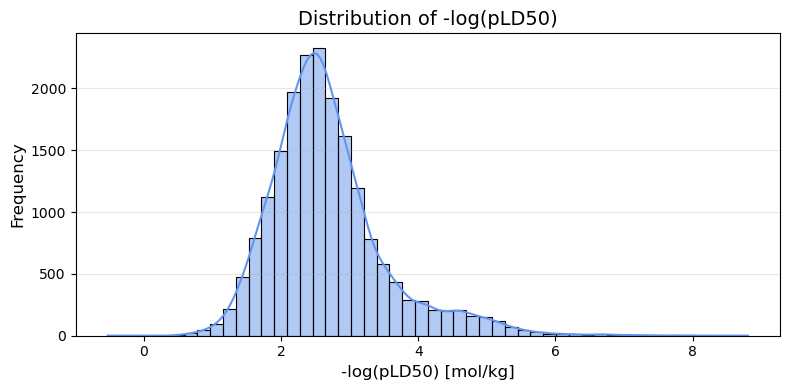

In [5]:
from utils_reg.pld50_distribution import plot_pld50_distribution
plot = plot_pld50_distribution(df_curated)
plot.savefig(f"{BASE_DIR}/outputs_reg/plots/pld50_distribution.png")
plot.show()

### Descriptors


In [6]:
from utils_reg.descriptors import descriptor_matrix

# Generate X and y
X, y = descriptor_matrix(df_curated, "SMILES", "pLD50")

# Full descriptor list for saving model components
full_descriptor_list = X.columns.tolist()

print(f"Descriptor matrix shape: {X.shape}")

Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 19221/19221 [03:47<00:00, 84.37it/s] 


Descriptor matrix shape: (19045, 217)


### Data split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    shuffle=True,
    test_size=0.3,
    random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 13331 | Test: 5714


In [8]:
from utils_reg.preprocessor import build_preprocessor
preprocessor = build_preprocessor()

# Process filtered and selected features for training and testing
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

### Feature filtering


In [ ]:
from utils_reg.filtering import filter_features

X_train_filtered, X_test_filtered = filter_features(X_train_proc, X_test_proc)

Variance Filter (threshold 0.01)


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

### Genetic Algorithm

In [ ]:
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import random

# ==========================================================
# GA Feature Selection (Regresión - Optimizado para precisión)
# ==========================================================


def ga_feature_selection(
    X,
    y,
    descriptor_names,
    n_gen=40,
    pop_size=60,
    random_state=42
):

    # ======================================================
    # Seeds
    # ======================================================
    np.random.seed(random_state)
    random.seed(random_state)

    X_np = X.values if hasattr(X, "values") else X
    n_features = X_np.shape[1]

    # ======================================================
    # CV (importante)
    # ======================================================
    cv = KFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    # ======================================================
    # Modelo base (NO lineal)
    # ======================================================
    model = RandomForestRegressor(
        n_estimators=120,        # balance costo / estabilidad
        max_depth=12,            # evita árboles enormes
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",     # reduce correlación entre árboles
        bootstrap=True,
        n_jobs=-1,               
        random_state=42
    )

    # ======================================================
    # Cache
    # ======================================================
    fitness_cache = {}
    MAX_CACHE = 10000

    # ======================================================
    # Fitness function
    # ======================================================
    def evaluate_individual(individual):

        key = tuple(individual)
        if key in fitness_cache:
            return fitness_cache[key]

        if len(fitness_cache) > MAX_CACHE:
            fitness_cache.clear()

        n_selected = sum(individual)

        MIN_FEATURES = max(5, int(0.01 * n_features))
        if n_selected < MIN_FEATURES:
            return (-1e6,)

        selected_idx = [i for i, bit in enumerate(individual) if bit == 1]
        X_sel = X_np[:, selected_idx]

        try:
            scores = cross_val_score(
                model,
                X_sel,
                y,
                cv=cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

            mean_score = scores.mean()   # negativo
            std_score = scores.std()

            rmse = -mean_score  # positivo

            # -----------------------------
            # Penalización ligera
            # -----------------------------
            lambda_penalty = 0.0005
            complexity_penalty = lambda_penalty * n_selected

            # -----------------------------
            # Penalización por inestabilidad
            # -----------------------------
            stability_penalty = 0.1 * std_score

            # -----------------------------
            # Fitness (maximizar)
            # -----------------------------
            fitness = -(rmse + complexity_penalty + stability_penalty)

        except Exception:
            fitness = -1e6

        fitness_cache[key] = (fitness,)
        return (fitness,)

    # ======================================================
    # DEAP setup
    # ======================================================
    if not hasattr(creator, "FitnessMax"):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()

    # ======================================================
    # Inicialización mejorada (NO sesgada)
    # ======================================================
    MIN_FEATURES = max(5, int(0.01 * n_features))

    def init_individual():
        ind = [0] * n_features

        k = int(np.random.normal(
            loc=0.1 * n_features,
            scale=0.05 * n_features
        ))

        k = np.clip(k, MIN_FEATURES, int(0.4 * n_features))

        selected = random.sample(range(n_features), int(k))

        for i in selected:
            ind[i] = 1

        return creator.Individual(ind)

    toolbox.register("individual", init_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # ======================================================
    # Operadores genéticos
    # ======================================================
    toolbox.register("evaluate", evaluate_individual)
    toolbox.register("mate", tools.cxTwoPoint)

    indpb = min(0.03, 2.0 / n_features)
    toolbox.register("mutate", tools.mutFlipBit, indpb=indpb)

    toolbox.register("select", tools.selTournament, tournsize=3)

    # ======================================================
    # Ejecución GA
    # ======================================================
    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    stats.register("min", np.min)
    stats.register("std", np.std)

    pop, log = algorithms.eaMuPlusLambda(
        pop,
        toolbox,
        mu=pop_size,
        lambda_=pop_size * 2,
        cxpb=0.6,
        mutpb=0.4,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    # ======================================================
    # Resultado final
    # ======================================================
    best_ind = hof[0]
    best_fitness = best_ind.fitness.values[0]

    selected_features = [
        descriptor_names[i]
        for i, bit in enumerate(best_ind)
        if bit == 1
    ]

    print("\n===== RESULTADO FINAL =====")
    print(f"Fitness: {best_fitness:.4f}")
    print(f"Número de features: {len(selected_features)}")

    return selected_features, best_fitness, hof, log

In [ ]:
#from utils_reg.robust_ga import ga_feature_selection

# Extract filtered feature names for ga
filtered_features = X_train_filtered.columns.tolist()

# Run GA
selected_features, best_fitness, hof, log = ga_feature_selection(
    X_train_filtered, y_train, filtered_features, n_gen=30, pop_size=50)

c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\elias\miniconda3\envs\qsar_classif_e

KeyboardInterrupt: 

In [ ]:
# Save selected features as dataframe
selected_features_df = pd.DataFrame(selected_features, columns=["Selected_Features"])
selected_features_df.to_csv(f"{BASE_DIR}/outputs_reg/reports/selected_features.csv", index=False)

In [ ]:
# Apply Ga features selection
X_train_proc = X_train_filtered[selected_features]
X_test_proc = X_test_filtered[selected_features]


### Training with optimization

In [ ]:
from utils_reg.optimization import optimize_model, save_model
from utils_reg.optimization import train_stacking_model

if model_name == "stacking":
    final_model = train_stacking_model(X_train_proc, y_train_enc)
    save_model(BASE_DIR, target, model_name, final_model,
            full_descriptor_list, selected_features, preprocessor)
    
else:
    final_model = optimize_model(X_train_proc, y_train_enc, model_name)
    save_model(BASE_DIR, target, model_name, final_model, 
            full_descriptor_list, selected_features, preprocessor)

[I 2026-03-31 22:32:34,241] A new study created in memory with name: xgb_study
[I 2026-03-31 22:32:40,165] Trial 0 finished with value: 0.6188466694617467 and parameters: {'n_estimators': 487, 'max_depth': 5, 'learning_rate': 0.08960785365368121, 'subsample': 0.779597545259111, 'colsample_bytree': 0.6468055921327309, 'gamma': 0.04679835610086079, 'min_child_weight': 1, 'reg_alpha': 0.21423021757741043, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.6188466694617467.
[I 2026-03-31 22:32:43,882] Trial 1 finished with value: 0.5981060468395916 and parameters: {'n_estimators': 654, 'max_depth': 3, 'learning_rate': 0.18276027831785724, 'subsample': 0.8497327922401265, 'colsample_bytree': 0.6637017332034828, 'gamma': 0.05454749016213018, 'min_child_weight': 2, 'reg_alpha': 0.00033205591037519585, 'reg_lambda': 0.12561043700013558}. Best is trial 0 with value: 0.6188466694617467.
[I 2026-03-31 22:32:46,811] Trial 2 finished with value: 0.608827810309078 and parameters: {'n_e


Model and components saved to: C:\ELIAS\xenotox/outputs_clf/pxr/models/best_model_pxr_xgb.pkl


### Internal validation

Metrics saved to: C:\ELIAS\xenotox/outputs_clf/pxr/reports/internal_validation_pxr_rf.csv
  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0    rf    pxr        0.5  0.844837       0.82578   0.675439  0.785714   

   Specificity  F1_score   ROC_AUC    PR_AUC       MCC  
0     0.865845  0.726415  0.900114  0.746263  0.622432  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


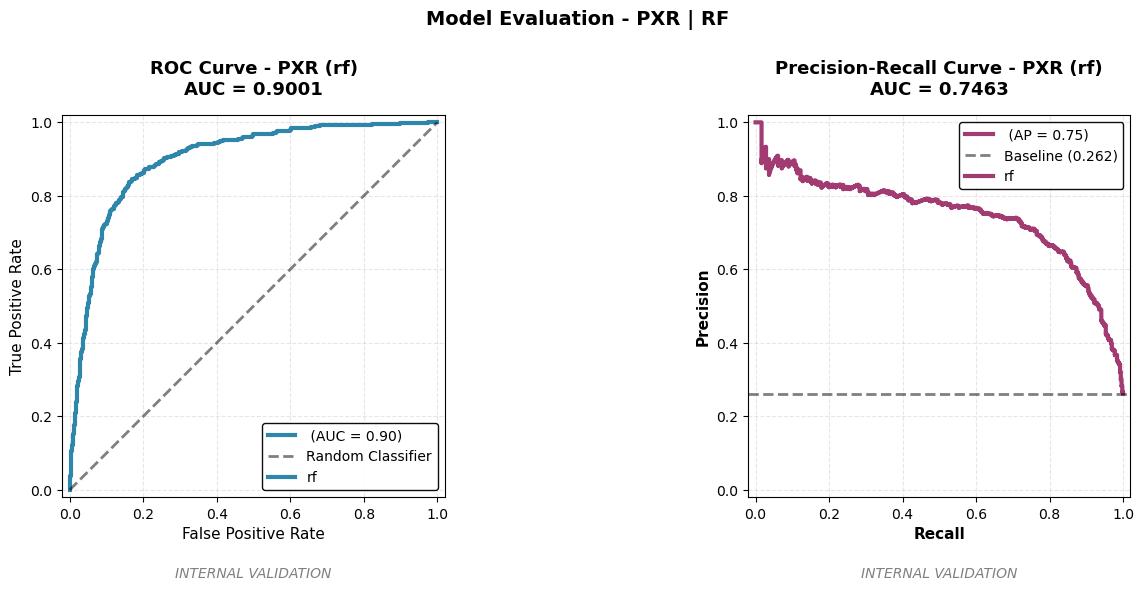

Plots saved to: C:\ELIAS\xenotox/outputs_clf/pxr/plots/internal_roc_pr_pxr_rf.png


ValueError: too many values to unpack (expected 2)

In [ ]:
from utils.validation import compute_metrics
plot, metrics = compute_metrics(BASE_DIR, final_model, X_test_proc, y_test_enc, "rf", target)
plot.show()

#Save metrics and plot
metrics.to_csv(f"{BASE_DIR}/outputs_clf/{target}/reports/internal_validation_{target}_{model_name}.csv", index=False)
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/internal_roc_pr_{target}_{model_name}.png", dpi=300)

### Applicability Domain (AD)


In [ ]:
from utils.applicability_domain import applicability_domain_analysis as ad
y_proba = metrics["y_proba"]
plot = ad(target, model_name, X_train_proc, X_test_proc, y_test_enc, y_proba)
plot.show()
# Save plot
plot.savefig(f"{BASE_DIR}/outputs_clf/{target}/plots/ad_{target}_{model_name}.png", dpi=300, bbox_inches="tight")

TypeError: applicability_domain_analysis() missing 1 required positional argument: 'y_proba'

### SHAP analysis

In [ ]:
from utils.shap import shap_top20
shap_top20(
    BASE_DIR=BASE_DIR,
    estimator=final_model,
    model_name=model_name,
    X_train_proc=X_train_proc,
    X_test_proc=X_test_proc,
    feature_names=selected_features,
    target=target
)


--- SHAP Top-10: xgb ---
   Background size: 100 samples
   SHAP analysis size: 500 samples


ValueError: could not convert string to float: '[5E-1]'

### External Validation

Curation completed: 306 valid molecules (out of 306 initial).
Initializing calculation with 2 cores...


RDKit progress: 100%|██████████| 306/306 [00:06<00:00, 45.13it/s]


Metrics saved to: C:\ELIAS\xenotox/outputs_clf/pxr/reports/external_validation_pxr_xgb.csv
  Model Target  Threshold  Accuracy  Bal_Accuracy  Precision    Recall  \
0   xgb    pxr        0.5  0.864486       0.87709   0.770492  0.989474   

   Specificity  F1_score   ROC_AUC    PR_AUC       MCC  
0     0.764706  0.866359  0.958249  0.942593  0.756896  


c:\Users\elias\miniconda3\envs\qsar_classif_env\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


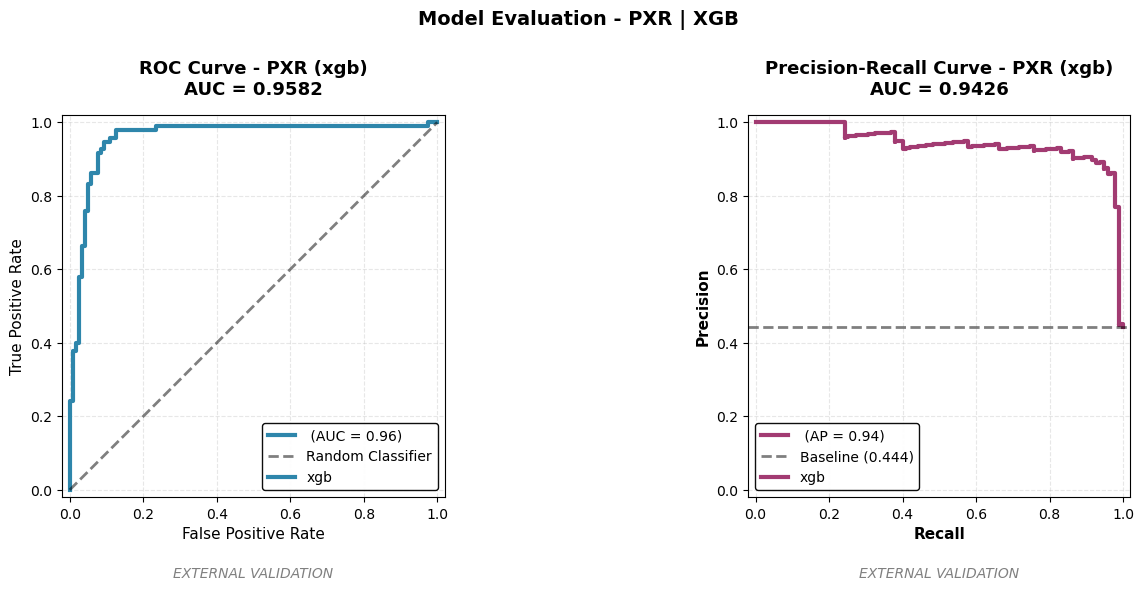

Plots saved to: C:\ELIAS\xenotox/outputs_clf/pxr/plots/external_roc_pr_pxr_xgb.png


In [ ]:
# Load external dataset
df_ext = pd.read_csv(f"{BASE_DIR}/ext_ligands/{target}/ext_{target}_ligands.csv")
# Curation
df_ext_curated = curate_data(df_ext,"SMILES", "Agonist_Activity")
# Descriptor calculation
X_ext, y_ext = descriptor_matrix(df_ext_curated, "SMILES", "Agonist_Activity")
# Split and encode labels
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext,
    stratify=y_ext,
    test_size=0.3,
    random_state=42
)
y_ext_train_enc = y_ext_train.map({"inactive": 0, "active": 1})
# Apply selected features to train set
X_ext_filtered = X_ext_train[selected_features]
# Preprocess
X_ext_proc = preprocessor.transform(X_ext_filtered)
# Evaluation
plot_ext, metrics_ext = compute_metrics(BASE_DIR, final_model, X_ext_proc, y_ext_train_enc, model_name, target, data_type="external")

# Save metrics and plot
metrics_ext.to_csv(
    f"{BASE_DIR}/outputs_clf/{target}/reports/external_validation_{target}_{model_name}.csv", index=False)
plot_ext.savefig(
    f"{BASE_DIR}/outputs_clf/{target}/plots/external_roc_pr_{target}_{model_name}.png", dpi=300)

Training set size: 4361
Number of descriptors: 42
AD threshold (h*): 0.0296
Compounds outside AD: 7.9% (17/214)
Leverage range - Train: [0.0012, 0.4122]
Leverage range - Test:  [0.0021, 0.1078]


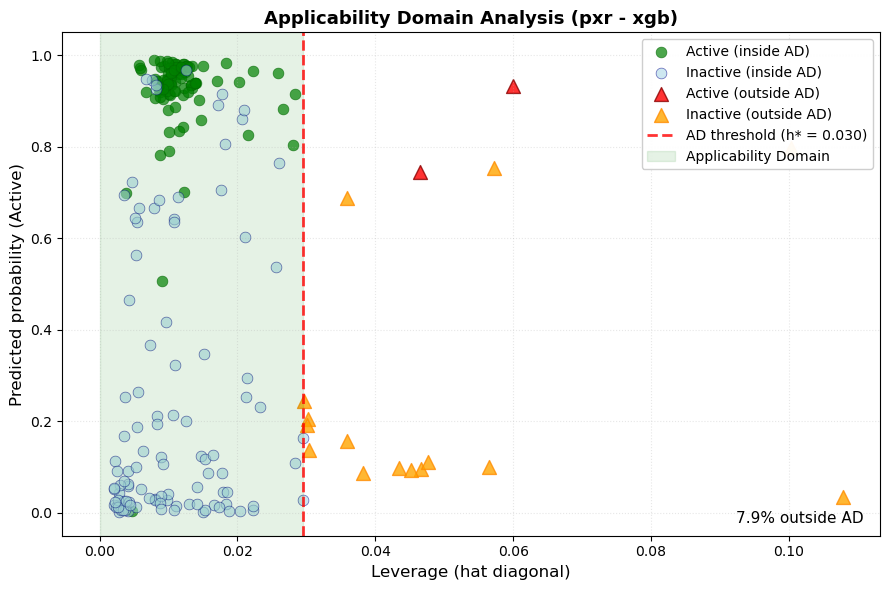


Plot saved to: C:\ELIAS\xenotox/outputs_clf/pxr/plots/ad_pxr_xgb.png


In [ ]:
# Applicability domain analysis for external set
y_ext_proba = metrics_ext["y_proba"]
ad(BASE_DIR, target, model_name, X_train_proc, X_ext_proc, y_ext_train_enc, y_ext_proba)